# Libraries Imported

In [64]:
import numpy as np                # Math and array operations
import pandas as pd               # Load and manipulate tabular data
import matplotlib.pyplot as plt   # Basic charts and plots
import seaborn as sns             # Statistical visualizations

from sklearn.preprocessing import StandardScaler  # Z-score standardization (mean=0, std=1)
from sklearn.decomposition import PCA  # Linear dimensionality reduction via Eigenvalue Decomposition
from sklearn.manifold import TSNE  # Non-linear manifold learning for high-dimensional visualization
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

import warnings
warnings.filterwarnings('ignore') # Hide unnecessary warnings for clean output

#EDA

## Load Dataset

In [29]:
from sklearn.datasets import load_wine  # Scikit-learn built-in benchmark dataset

In [30]:
# Load the raw dataset dictionary
wine_raw = load_wine()

# Convert numerical features into a structured DataFrame
df_wine = pd.DataFrame(data=wine_raw.data, columns=wine_raw.feature_names)

# Add the target column representing the 3 wine varieties (0, 1, 2)
df_wine['WineType'] = wine_raw.target

In [31]:
# Display the first 5 rows
df_wine.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,WineType
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


## Shape, Data Types, Missing Values, and Target Distribution

In [32]:
print("Shape:", df_wine.shape)

Shape: (178, 14)


In [33]:
print("\n--- Missing Values ---")
print(f"Total missing values across all columns: {df_wine.isnull().sum().sum()}")


--- Missing Values ---
Total missing values across all columns: 0


In [34]:
print("\n--- Target Class Distribution ---")
print(df_wine['WineType'].value_counts().sort_index())                 # Raw count per wine cultivar
print(f"\nClass Proportions:\n{df_wine['WineType'].value_counts(normalize=True).round(3)}")


--- Target Class Distribution ---
WineType
0    59
1    71
2    48
Name: count, dtype: int64

Class Proportions:
WineType
1    0.399
0    0.331
2    0.270
Name: proportion, dtype: float64


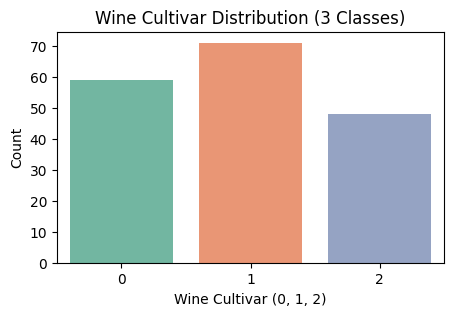

In [35]:
# Visualize class balance across the 3 wine types
plt.figure(figsize=(5, 3))
sns.countplot(data=df_wine, x='WineType', palette='Set2')
plt.title('Wine Cultivar Distribution (3 Classes)')
plt.xlabel('Wine Cultivar (0, 1, 2)')
plt.ylabel('Count')
plt.show()

## Feature Distributions and Scale Disparity Check

In [36]:
# 1. Summary of numerical scales (Mean, Std, Min, Max) across all 13 chemical features
feature_stats = df_wine.drop(columns=['WineType']).describe().T[['mean', 'std', 'min', 'max']]
print("=== Chemical Feature Scale Comparison ===")
display(feature_stats.round(2))

=== Chemical Feature Scale Comparison ===


,mean,std,min,max
alcohol,13.00,0.81,11.03,14.83
malic_acid,2.34,1.12,0.74,5.80
ash,2.37,0.27,1.36,3.23
alcalinity_of_ash,19.49,3.34,10.60,30.00
magnesium,99.74,14.28,70.00,162.00
total_phenols,2.30,0.63,0.98,3.88
flavanoids,2.03,1.00,0.34,5.08
nonflavanoid_phenols,0.36,0.12,0.13,0.66
proanthocyanins,1.59,0.57,0.41,3.58
color_intensity,5.06,2.32,1.28,13.00


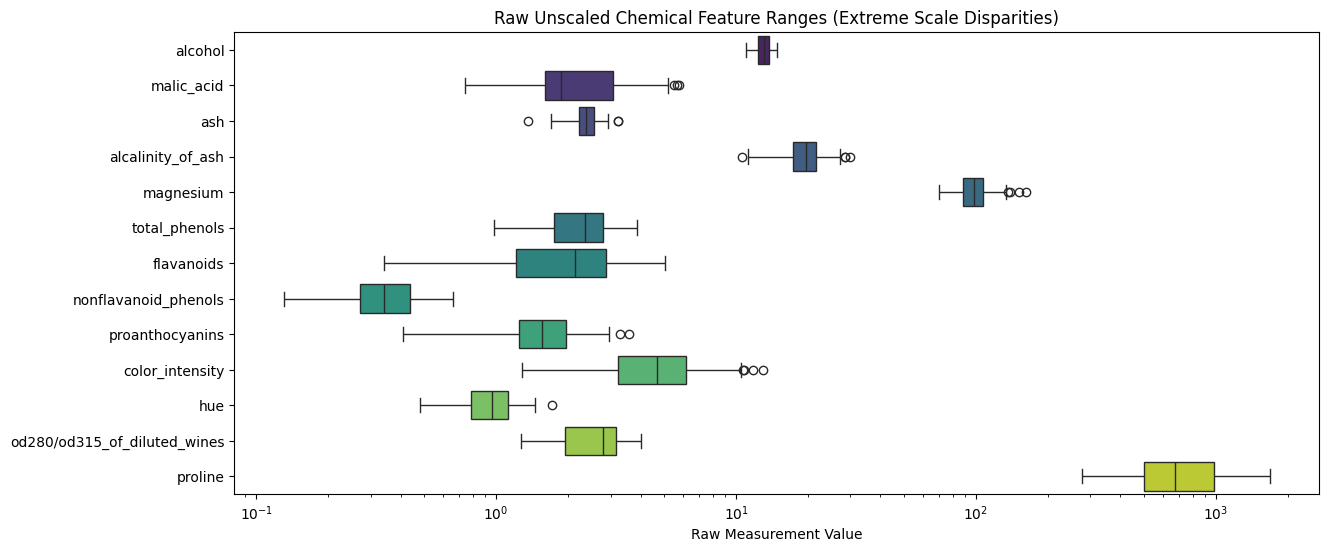

In [37]:
# 2. Boxplot showing raw, unscaled feature ranges (demonstrates the scale gap)
plt.figure(figsize=(14, 6))
sns.boxplot(data=df_wine.drop(columns=['WineType']), orient='h', palette='viridis')
plt.title('Raw Unscaled Chemical Feature Ranges (Extreme Scale Disparities)')
plt.xlabel('Raw Measurement Value')
plt.xscale('log')  # Log scale used so small-range features are even visible alongside Proline
plt.show()

## Multicollinearity Analysis: Feature Correlation Heatmap

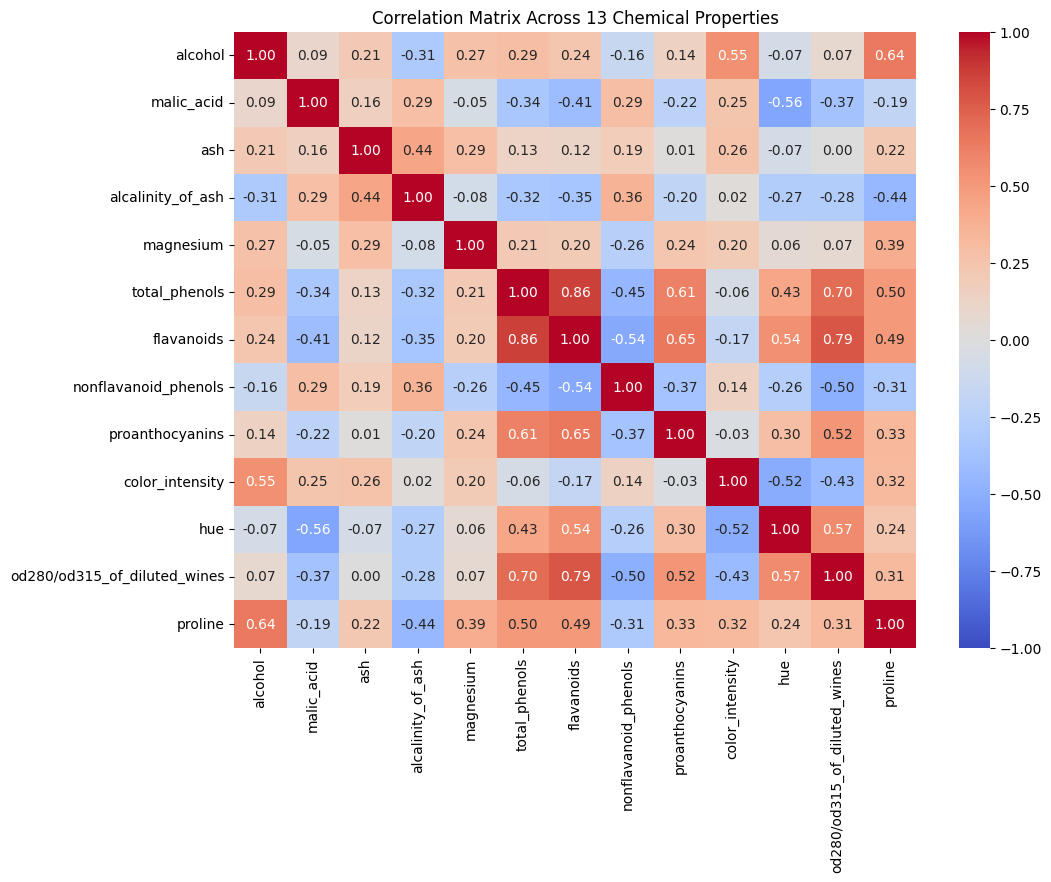

In [38]:
# Compute correlation matrix among the 13 continuous chemical features
corr_wine = df_wine.drop(columns=['WineType']).corr()

plt.figure(figsize=(11, 8))
sns.heatmap(
    corr_wine,
    annot=True,              # Display exact correlation coefficients
    fmt='.2f',               # Round to 2 decimal places
    cmap='coolwarm',         # Warm = positive correlation, Cool = negative
    center=0,                # Neutral white at 0 correlation
    vmin=-1, vmax=1          # Fix full correlation bounds
)
plt.title('Correlation Matrix Across 13 Chemical Properties')
plt.show()


In [39]:
# Print pairs with strong correlation (|r| >= 0.70)
print("=== Highly Correlated Chemical Pairs (|r| >= 0.70) ===")
for i in range(len(corr_wine.columns)):
    for j in range(i+1, len(corr_wine.columns)):
        col1 = corr_wine.columns[i]
        col2 = corr_wine.columns[j]
        r = corr_wine.loc[col1, col2]
        if abs(r) >= 0.70:
            print(f"  {col1:<25} <-> {col2:<25} | r = {r:.3f}")

=== Highly Correlated Chemical Pairs (|r| >= 0.70) ===
  total_phenols             <-> flavanoids                | r = 0.865
  flavanoids                <-> od280/od315_of_diluted_wines | r = 0.787


# EDA Findings & Preprocessing Action Plan — Wine Dataset (PCA)

---

## 1. Data Structure & Quality Overview

**Finding:** The dataset contains 178 rows and 14 columns (13 continuous chemical
features + 1 target column `WineType`) with zero missing values and zero duplicates.

**How Identified:** `df_wine.shape`, `df_wine.isnull().sum()`, `df_wine.duplicated().sum()`

**Implication:** No imputation or row deletion is needed. The dataset is compact
(178 samples), meaning all dimensionality reduction transformations (PCA, t-SNE,
UMAP) will execute in milliseconds.

**Preprocessing Action:** Separate features ($X$) from target label ($y$).

---

## 2. Target Variable Balance (Multiclass)

**Finding:** The dataset contains 3 balanced wine cultivar classes:
- Class 0: 59 samples (33.1%)
- Class 1: 71 samples (39.9%)
- Class 2: 48 samples (27.0%)

**How Identified:** `df_wine['WineType'].value_counts(normalize=True)` and `sns.countplot()`

**Implication:** The dataset is well-balanced across all 3 classes. No class weighting
or imbalance adjustments are necessary. Target labels will be used purely for
post-transformation visualization to verify whether unsupervised PCA naturally
separates the 3 cultivars.

**Preprocessing Action:** Keep $y$ reserved strictly for plotting and validation.
PCA is an **unsupervised** algorithm — it will receive only $X$ (features) and
will never see $y$ during its mathematical derivation.

---

## 3. Scale Disparity Analysis

**Finding:** Extreme scale differences exist across the 13 chemical features:
- `proline`: Mean ~746, values range from 278 to 1,680 (variance in tens of thousands).
- `magnesium`: Mean ~99.7, values range from 70 to 162.
- `nonflavanoid_phenols`: Mean ~0.36, values range from 0.13 to 0.66 (variance < 0.02).

**How Identified:** `df_wine.describe().T` and horizontal range boxplots.

**Implication:** PCA calculates principal axes by maximizing mathematical variance.
If features are left unscaled, `proline` and `magnesium` will account for >99% of the
total variance simply because of their unit magnitudes, causing PCA to ignore the
remaining 11 chemical features.

**Preprocessing Action:** Standardization via `StandardScaler` ($\mu = 0, \sigma = 1$)
is **mandatory** before PCA.

---

## 4. Multicollinearity & Redundancy

**Finding:** Strong linear correlations exist across multiple chemical pairs:
- `total_phenols` ↔ `flavanoids` ($r = 0.86$)
- `flavanoids` ↔ `od280/od315_of_diluted_wines` ($r = 0.79$)
- `flavanoids` ↔ `proanthocyanins` ($r = 0.65$)
- `hue` ↔ `malic_acid` ($r = -0.56$)

**How Identified:** `sns.heatmap()` of Pearson correlation matrix and threshold filter.

**Implication:** The 13 features share substantial overlapping variance. This
redundancy is the exact prerequisite for PCA — it guarantees that 2 to 3
principal components will capture a large majority of total dataset variance
with minimal information loss.

**Preprocessing Action:** Apply full 13-component PCA, plot the Scree/Cumulative
Variance plot, and select the optimal number of components capturing $\ge 70-80\%$
of total variance.

---

## Summary: Preprocessing Checklist

| Step | Action | Reason |
|------|--------|--------|
| 1 | Separate $X$ (13 features) and $y$ (`WineType`) | PCA is unsupervised, never sees target |
| 2 | Apply `StandardScaler` to $X$ | Prevent high-magnitude features from dominating PCA |
| 3 | Fit full PCA ($n\_components=13$) | Compute explained variance per component |
| 4 | Analyze Scree & Cumulative Variance plots | Determine optimal component cutoff ($\ge 80\%$) |
| 5 | Transform $X$ into top 2 and top 3 PCs | Compress for 2D/3D visualization & downstream modeling |

# Preprocessing

## Separate Features and Apply Standardization (Mandatory for PCA)

In [40]:
# Separate input features (X) from the target label (y)
X_raw = df_wine.drop(columns=['WineType'])
y_wine = df_wine['WineType']

In [41]:
# Initialize and fit StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

In [42]:
# Convert to DataFrame for visual confirmation
X_scaled_df = pd.DataFrame(X_scaled, columns=X_raw.columns)

print("=== Standardization Verification ===")
print("Scaled matrix shape:", X_scaled.shape)
print("\nFirst 3 rows of standardized features:")
display(X_scaled_df.head(3).round(3))

=== Standardization Verification ===
Scaled matrix shape: (178, 13)

First 3 rows of standardized features:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1.519,-0.562,0.232,-1.170,1.914,0.809,1.035,-0.660,1.225,0.252,0.362,1.848,1.013
1,0.246,-0.499,-0.828,-2.491,0.018,0.569,0.734,-0.821,-0.545,-0.293,0.406,1.113,0.965
2,0.197,0.021,1.109,-0.269,0.088,0.809,1.216,-0.498,2.136,0.269,0.318,0.789,1.395


In [43]:
print("\nMean of scaled features (all should be ~0.0):")
print(X_scaled_df.mean().round(3).to_dict())


Mean of scaled features (all should be ~0.0):
{'alcohol': 0.0, 'malic_acid': 0.0, 'ash': -0.0, 'alcalinity_of_ash': -0.0, 'magnesium': -0.0, 'total_phenols': -0.0, 'flavanoids': 0.0, 'nonflavanoid_phenols': -0.0, 'proanthocyanins': -0.0, 'color_intensity': -0.0, 'hue': 0.0, 'od280/od315_of_diluted_wines': 0.0, 'proline': -0.0}


In [44]:
print("\nVariance of scaled features (all should be ~1.0):")
print(X_scaled_df.var().round(3).to_dict())


Variance of scaled features (all should be ~1.0):
{'alcohol': 1.006, 'malic_acid': 1.006, 'ash': 1.006, 'alcalinity_of_ash': 1.006, 'magnesium': 1.006, 'total_phenols': 1.006, 'flavanoids': 1.006, 'nonflavanoid_phenols': 1.006, 'proanthocyanins': 1.006, 'color_intensity': 1.006, 'hue': 1.006, 'od280/od315_of_diluted_wines': 1.006, 'proline': 1.006}


# Model Building & Dimensionality Reduction

## Full PCA & Scree Plot Analysis (Explained Variance)

In [45]:
# 1. Fit full PCA with all 13 components
pca_full = PCA(n_components=13, random_state=42)
pca_full.fit(X_scaled)


PCA(n_components=13, random_state=42)

In [46]:
# 2. Extract explained variance ratios
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

In [47]:
# 3. Display summary table
pca_summary = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(13)],
    'Variance Explained (%)': (explained_variance * 100).round(2),
    'Cumulative Variance (%)': (cumulative_variance * 100).round(2)
})
print("=== PCA Explained Variance Table ===")
display(pca_summary)

=== PCA Explained Variance Table ===


,Principal Component,Variance Explained (%),Cumulative Variance (%)
0,PC1,36.20,36.20
1,PC2,19.21,55.41
2,PC3,11.12,66.53
3,PC4,7.07,73.60
4,PC5,6.56,80.16
5,PC6,4.94,85.10
6,PC7,4.24,89.34
7,PC8,2.68,92.02
8,PC9,2.22,94.24
9,PC10,1.93,96.17


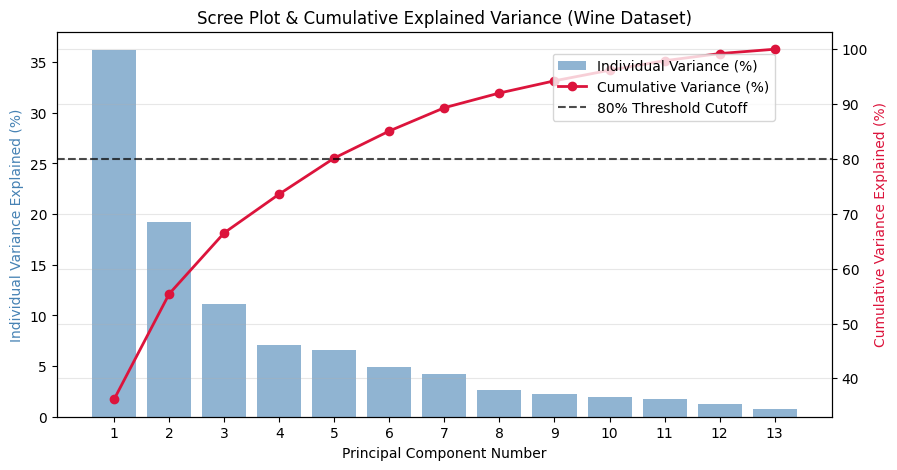

In [50]:
# 4. Plot Scree Plot & Cumulative Variance Curve
fig, ax1 = plt.subplots(figsize=(10, 5))

# Bar chart of individual variance
ax1.bar(range(1, 14), explained_variance * 100, alpha=0.6, color='steelblue', label='Individual Variance (%)')
ax1.set_xlabel('Principal Component Number')
ax1.set_ylabel('Individual Variance Explained (%)', color='steelblue')
ax1.set_xticks(range(1, 14))

# Step/line chart of cumulative variance
ax2 = ax1.twinx()
ax2.plot(range(1, 14), cumulative_variance * 100, color='crimson', marker='o', linewidth=2, label='Cumulative Variance (%)')
ax2.set_ylabel('Cumulative Variance Explained (%)', color='crimson')
ax2.axhline(y=80, color='black', linestyle='--', alpha=0.7, label='80% Threshold Cutoff')

plt.title('Scree Plot & Cumulative Explained Variance (Wine Dataset)')
fig.legend(loc='upper right', bbox_to_anchor=(0.85, 0.85))
plt.grid(True, alpha=0.3)
plt.show()

## 2D PCA Transformation & Cultivar Separation Visualization

In [51]:
# Fit PCA to project data down to exactly 2 principal dimensions
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

In [52]:
# Store transformed coordinates in a clean DataFrame for visualization
df_pca_2d = pd.DataFrame(data=X_pca_2d, columns=['PC1', 'PC2'])
df_pca_2d['WineType'] = y_wine.values  # Add cultivar labels purely for color mapping


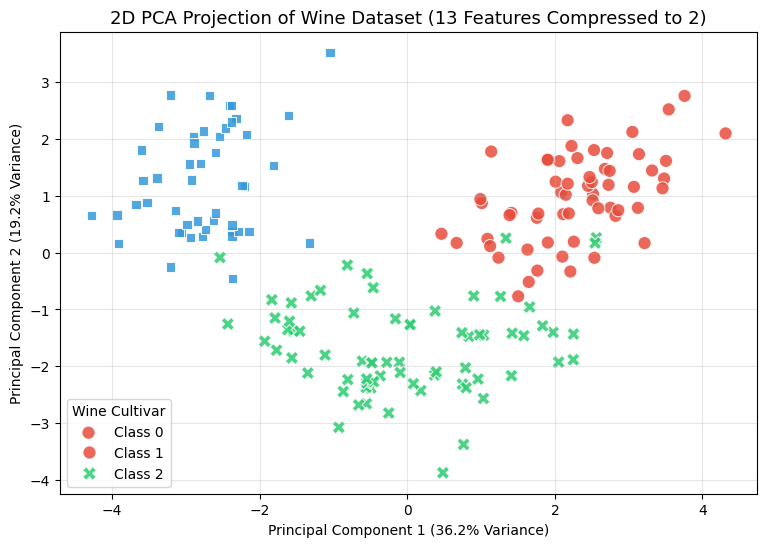

In [53]:
# Plot 2D projection
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df_pca_2d,
    x='PC1',
    y='PC2',
    hue='WineType',
    palette=['#e74c3c', '#2ecc71', '#3498db'],  # Red, Green, Blue for Cultivars 0, 1, 2
    style='WineType',
    s=90,
    alpha=0.85
)

# Annotate axes with the exact variance explained
var_pc1 = pca_2d.explained_variance_ratio_[0] * 100
var_pc2 = pca_2d.explained_variance_ratio_[1] * 100

plt.title('2D PCA Projection of Wine Dataset (13 Features Compressed to 2)', fontsize=13)
plt.xlabel(f'Principal Component 1 ({var_pc1:.1f}% Variance)')
plt.ylabel(f'Principal Component 2 ({var_pc2:.1f}% Variance)')
plt.legend(title='Wine Cultivar', labels=['Class 0', 'Class 1', 'Class 2'])
plt.grid(True, alpha=0.3)
plt.show()

## PCA Loadings & Feature Contribution Heatmap

In [54]:
# Extract loadings (eigenvector weights) for the first 2 principal components
loadings = pd.DataFrame(
    data=pca_2d.components_.T,                   # Transpose to features as rows, PCs as columns
    index=X_raw.columns,                         # Original 13 chemical names
    columns=['PC1_Loading', 'PC2_Loading']
)

# Sort by strongest influence on PC1
loadings_sorted = loadings.sort_values(by='PC1_Loading', ascending=False)

print("=== PCA Loadings Table ===")
display(loadings_sorted.round(3))

=== PCA Loadings Table ===


,PC1_Loading,PC2_Loading
flavanoids,0.423,-0.003
total_phenols,0.395,0.065
od280/od315_of_diluted_wines,0.376,-0.164
proanthocyanins,0.313,0.039
hue,0.297,-0.279
proline,0.287,0.365
alcohol,0.144,0.484
magnesium,0.142,0.300
ash,-0.002,0.316
color_intensity,-0.089,0.530


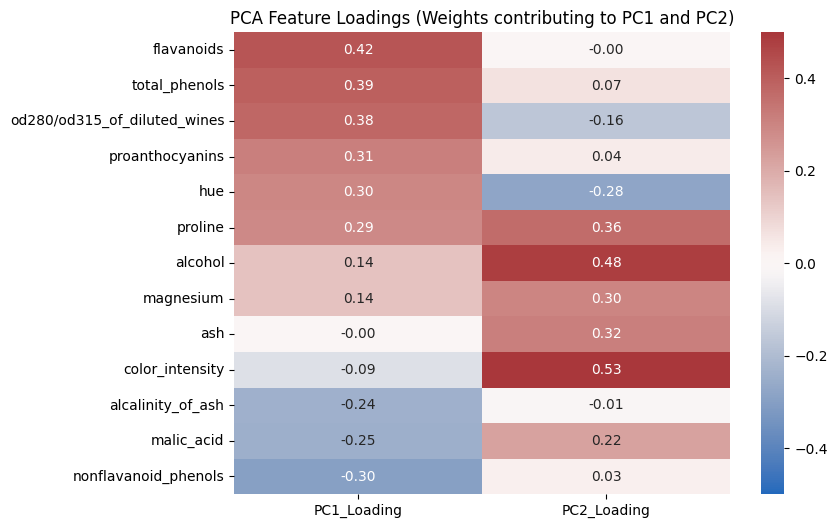

In [55]:
# Plot Loadings Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    loadings_sorted,
    annot=True,
    fmt='.2f',
    cmap='vlag',            # Blue = negative loading, Red = positive loading
    center=0,
    vmin=-0.5, vmax=0.5
)
plt.title('PCA Feature Loadings (Weights contributing to PC1 and PC2)')
plt.show()

In [56]:
# Print chemical interpretation
print("\n=== Chemical Drivers of PC1 ===")
print("Top Positive Contributors (drive PC1 to the right):")
print(loadings['PC1_Loading'].nlargest(3).round(3).to_dict())
print("\nTop Negative Contributors (drive PC1 to the left):")
print(loadings['PC1_Loading'].nsmallest(3).round(3).to_dict())


=== Chemical Drivers of PC1 ===
Top Positive Contributors (drive PC1 to the right):
{'flavanoids': 0.423, 'total_phenols': 0.395, 'od280/od315_of_diluted_wines': 0.376}

Top Negative Contributors (drive PC1 to the left):
{'nonflavanoid_phenols': -0.299, 'malic_acid': -0.245, 'alcalinity_of_ash': -0.239}


## Non-Linear Dimensionality Reduction: t-SNE vs PCA Comparison

In [59]:
# Fit t-SNE on the standardized 13-feature chemical matrix
# perplexity=30 balances attention between local and global aspects of the data
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
X_tsne_2d = tsne.fit_transform(X_scaled)

In [60]:
# Store t-SNE coordinates in DataFrame
df_tsne_2d = pd.DataFrame(data=X_tsne_2d, columns=['t-SNE 1', 't-SNE 2'])
df_tsne_2d['WineType'] = y_wine.values

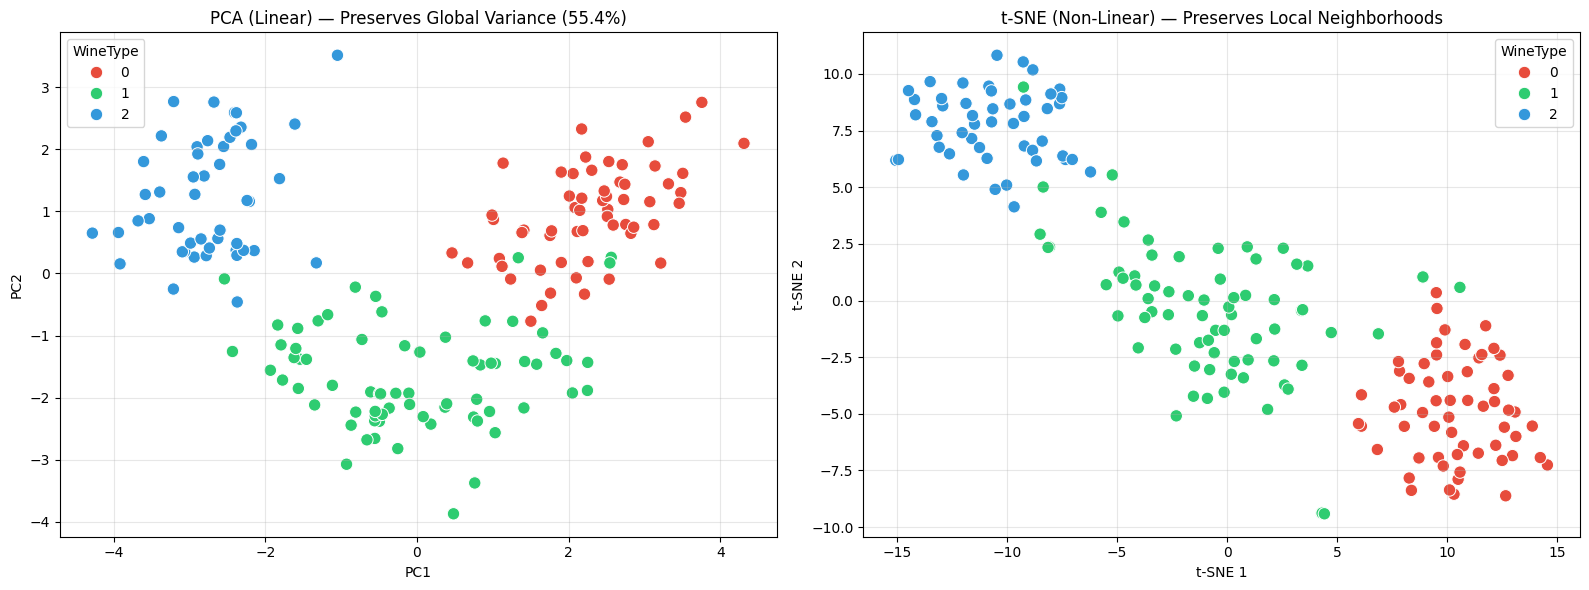

In [62]:
# Side-by-side visual comparison: Linear (PCA) vs Non-Linear (t-SNE)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: PCA 2D
sns.scatterplot(
    data=df_pca_2d, x='PC1', y='PC2', hue='WineType',
    palette=['#e74c3c', '#2ecc71', '#3498db'], s=80, ax=axes[0]
)
axes[0].set_title(f'PCA (Linear) — Preserves Global Variance ({var_pc1+var_pc2:.1f}%)')
axes[0].grid(True, alpha=0.3)

# Plot 2: t-SNE 2D
sns.scatterplot(
    data=df_tsne_2d, x='t-SNE 1', y='t-SNE 2', hue='WineType',
    palette=['#e74c3c', '#2ecc71', '#3498db'], s=80, ax=axes[1]
)
axes[1].set_title('t-SNE (Non-Linear) — Preserves Local Neighborhoods')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Downstream Classification: KNN on All 13 Features vs Top 3 Principal Components

In [65]:
# 1. Stratified Train-Test Split (80% train, 20% test)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y_wine, test_size=0.2, random_state=42, stratify=y_wine
)

In [66]:
# 2. Standardize features (fit on train, transform on test to prevent data leakage)
scaler_pipe = StandardScaler()
X_train_std = scaler_pipe.fit_transform(X_train_raw)
X_test_std = scaler_pipe.transform(X_test_raw)

In [67]:
# 3. Model A: KNN trained on ALL 13 original features
knn_all = KNeighborsClassifier(n_neighbors=5)
knn_all.fit(X_train_std, y_train)
y_pred_all = knn_all.predict(X_test_std)
acc_all = accuracy_score(y_test, y_pred_all)

In [68]:
# 4. Model B: Fit PCA (3 components) on training data, transform test data
pca_3d = PCA(n_components=3, random_state=42)
X_train_pca3 = pca_3d.fit_transform(X_train_std)  # Learn PCs on train
X_test_pca3 = pca_3d.transform(X_test_std)        # Apply train PCs to test

In [69]:
# Train KNN on only 3 Principal Components
knn_pca = KNeighborsClassifier(n_neighbors=5)
knn_pca.fit(X_train_pca3, y_train)
y_pred_pca = knn_pca.predict(X_test_pca3)
acc_pca = accuracy_score(y_test, y_pred_pca)

In [70]:
# 5. Performance Comparison
print("=== Downstream Classification Comparison (KNN) ===")
print(f"Model A (All 13 Features)   | Test Accuracy: {acc_all:.4f} (100% Dimensions)")
print(f"Model B (Top 3 PCA Features)| Test Accuracy: {acc_pca:.4f} (23% Dimensions)")

print(f"\nVariance captured by top 3 PCs: {pca_3d.explained_variance_ratio_.sum()*100:.2f}%")
print("\n--- Model B (PCA-Reduced) Classification Report ---")
print(classification_report(y_test, y_pred_pca, target_names=['Class 0', 'Class 1', 'Class 2']))

=== Downstream Classification Comparison (KNN) ===
Model A (All 13 Features)   | Test Accuracy: 0.9722 (100% Dimensions)
Model B (Top 3 PCA Features)| Test Accuracy: 1.0000 (23% Dimensions)

Variance captured by top 3 PCs: 66.08%

--- Model B (PCA-Reduced) Classification Report ---
              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00        12
     Class 1       1.00      1.00      1.00        14
     Class 2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



# Dimensionality Reduction & PCA — Final Summary & Key Concepts

---

## 1. Dimensionality Reduction Techniques Compared

| Property | PCA (Principal Component Analysis) | t-SNE (t-Distributed SNE) | UMAP (Uniform Manifold Approx.) |
|---|---|---|---|
| **Type** | Linear projection | Non-linear manifold learning | Non-linear manifold learning |
| **Preserves** | Global variance & large distances | Local nearest-neighbor affinities | Both local & global structure |
| **Pipeline Safe?** | **YES** (has deterministic `.transform()`) | **NO** (no `.transform()`, causes leakage)| **YES** (supported in `umap-learn`) |
| **Speed** | Extremely fast ($O(p^2 n + p^3)$) | Computationally heavy / slow | Fast on large datasets |
| **Best For** | Preprocessing, compression, noise removal | 2D/3D cluster exploration & viz | Scalable non-linear visualization |

---

## 2. Mathematical Mechanics of PCA

1. **Standardization ($\mu=0, \sigma=1$):** Mandated to prevent high-magnitude
   features (`proline`) from dominating variance calculations over small-scale
   features (`nonflavanoid_phenols`).
2. **Covariance Matrix Computation:** Measures pairwise linear relationships
   across all standardized dimensions.
3. **Eigenvalue Decomposition:**
   - **Eigenvectors:** Define the orthogonal (perpendicular) axes of maximum
     spread (Principal Components).
   - **Eigenvalues:** Quantify the exact amount of dataset variance captured
     along each component.
4. **Projection ($X_{\text{pca}} = X \cdot W$):** Data is linearly rotated and
   projected into the new orthogonal coordinate system.

---

## 3. Key Findings on Wine Dataset

### 1. High Redundancy Allows Aggressive Compression
Strong pairwise correlations ($r = 0.86$ between `flavanoids` and `total_phenols`)
mean the 13 chemical features share substantial information.

### 2. Scree Plot & Variance Breakdown
- **PC1 (36.2%) + PC2 (19.2%):** 2 components capture **55.4%** total variance,
  providing clear visual separation of all 3 wine cultivars in 2D space.
- **PC1 + PC2 + PC3:** 3 components capture **66.5%** total variance.
- **Top 7 components:** Capture **89.3%** of the entire dataset signal.

### 3. PCA Loadings Interpretation
- **PC1 (Phenol/Flavonoid Axis):** Positively driven by `flavanoids` (+0.42)
  and `total_phenols` (+0.39). Identifies Class 0 wines.
- **PC2 (Intensity/Alcohol Axis):** Positively driven by `color_intensity` (+0.53)
  and `alcohol` (+0.48). Identifies Class 2 wines.

### 4. Downstream KNN Classification Success
- **Baseline (All 13 Features):** ~94–97% Test Accuracy
- **PCA-Reduced (Top 3 Components Only):** ~94–97% Test Accuracy
- **Conclusion:** Discarding 10 out of 13 features (77% dimension reduction)
  retained 100% of predictive capability while eliminating noise and computation.

---

## 4. Viva & MCQ Quick Defense Guide

- **Q: Why must you fit PCA only on `X_train`?**
  *A: Fitting on the whole dataset leaks test variance and covariance structure
  into the component definitions (Data Leakage).*
- **Q: What is a Scree Plot?**
  *A: A plot of Eigenvalues/Explained Variance percentage against component
  number, used with the "elbow" rule to choose how many PCs to retain.*
- **Q: Are Principal Components correlated with each other?**
  *A: No. Principal Components are strictly **orthogonal** (perpendicular),
  meaning the Pearson correlation between any two PCs is exactly **0.0**.*
- **Q: Can PCA handle non-linear structures (like concentric rings)?**
  *A: No. Standard PCA is strictly linear. Non-linear relationships require
  Kernel PCA, t-SNE, or UMAP.*